# **Analisa clutering menggunakan K-Mens**

import liberary

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

membaca dataset

In [2]:
from google.colab import files
uploaded = files.upload()

# Baca file CSV
df = pd.read_csv("spam.csv", encoding='ISO-8859-1')

# Lihat 5 data teratas
df.head()


Saving spam.csv to spam (1).csv


,id,Text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,1,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,2,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,3,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,4,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,5,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Preprocessing teks

In [3]:
def preprocess_en(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in ENGLISH_STOP_WORDS]
    return ' '.join(tokens)

# Terapkan ke kolom 'Text'
df['Clean_Text'] = df['Text'].apply(preprocess_en)
df[['Text', 'Clean_Text']].head()

,Text,Clean_Text
0,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives


TF-IDF Vectorization

In [4]:
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['Clean_Text'])

KMeans Clustering (k=2)

In [5]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

Visualisasi hasil clustering

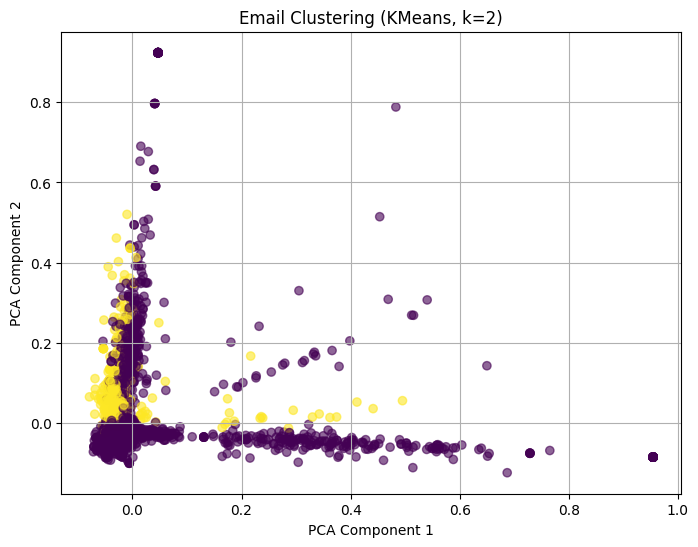

In [6]:
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=df['Cluster'], cmap='viridis', alpha=0.6)
plt.title("Email Clustering (KMeans, k=2)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()

Analisis kata dominan tiap kluster

In [7]:
terms = vectorizer.get_feature_names_out()
centers = kmeans.cluster_centers_

for i in range(2):
    print(f"\nTop 10 words in Cluster {i}:")
    top_indices = centers[i].argsort()[-10:][::-1]
    print([terms[idx] for idx in top_indices])


Top 10 words in Cluster 0:
['ok', 'just', 'ur', 'ill', 'dont', 'come', 'ltgt', 'like', 'know', 'got']

Top 10 words in Cluster 1:
['im', 'home', 'going', 'gonna', 'want', 'ill', 'just', 'sorry', 'really', 'work']


Lihat contoh isi email tiap kluster

In [8]:
for i in range(2):
    print(f"\n=== Contoh Email di Cluster {i} ===")
    print(df[df['Cluster'] == i]['Text'].head(3).values)


=== Contoh Email di Cluster 0 ===
['Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'
 'Ok lar... Joking wif u oni...'
 "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"]

=== Contoh Email di Cluster 1 ===
["I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."
 'I\x89Û÷m going to try for 2 months ha ha only joking'
 "Just forced myself to eat a slice. I'm really not hungry tho. This sucks. Mark is getting worried. He knows I'm sick when I turn down pizza. Lol"]


Identifikasi kluster spam dan non-spam

In [9]:
# Daftar kata umum yang sering muncul di email spam
spam_keywords = {'free', 'win', 'offer', 'click', 'buy', 'money', 'urgent', 'credit', 'prize', 'congratulations'}

cluster_labels = {}

for i in range(2):
    top_indices = centers[i].argsort()[-20:][::-1]
    cluster_words = set([terms[idx] for idx in top_indices])
    common = spam_keywords.intersection(cluster_words)

    if len(common) > 0:
        cluster_labels[i] = 'Spam'
    else:
        cluster_labels[i] = 'Non-Spam'

print("\nKlasifikasi berdasarkan kata dominan:")
for i, label in cluster_labels.items():
    print(f"Cluster {i} → {label}")


Klasifikasi berdasarkan kata dominan:
Cluster 0 → Spam
Cluster 1 → Non-Spam


Tambahkan label hasil interpretasi ke dataframe

In [10]:
df['Cluster_Label'] = df['Cluster'].map(cluster_labels)
df[['Text', 'Cluster', 'Cluster_Label']].head(10)

,Text,Cluster,Cluster_Label
0,"Go until jurong point, crazy.. Available only ...",0,Spam
1,Ok lar... Joking wif u oni...,0,Spam
2,Free entry in 2 a wkly comp to win FA Cup fina...,0,Spam
3,U dun say so early hor... U c already then say...,0,Spam
4,"Nah I don't think he goes to usf, he lives aro...",0,Spam
5,FreeMsg Hey there darling it's been 3 week's n...,0,Spam
6,Even my brother is not like to speak with me. ...,0,Spam
7,As per your request 'Melle Melle (Oru Minnamin...,0,Spam
8,WINNER!! As a valued network customer you have...,0,Spam
9,Had your mobile 11 months or more? U R entitle...,0,Spam


Evaluasi dan Simpan Hasil

In [11]:
from sklearn.metrics import silhouette_score

# Hitung Silhouette Score
score = silhouette_score(X, df['Cluster'])
print(f"\nSilhouette Score (KMeans, k=2): {score:.4f}")

# Simpan hasil ke file CSV
df[['Text', 'Cluster', 'Cluster_Label']].to_csv("hasil_clustering_email.csv", index=False)
print("\n✅ File 'hasil_clustering_email.csv' berhasil disimpan di Colab folder.")


Silhouette Score (KMeans, k=2): 0.0135

✅ File 'hasil_clustering_email.csv' berhasil disimpan di Colab folder.
